In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

df = pd.read_excel('1000-Supermarket-Sales.xlsx')

### Exploratory Analysis

In [2]:
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-05-01,13:08:00,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-08-03,10:29:00,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,13:23:00,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,20:33:00,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2019-08-02,10:37:00,Ewallet,604.17,4.761905,30.2085,5.3


In [3]:
df.isnull().sum()

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Total                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

In [4]:
df.duplicated().sum()


np.int64(0)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   str    
 1   Branch                   1000 non-null   str    
 2   City                     1000 non-null   str    
 3   Customer type            1000 non-null   str    
 4   Gender                   1000 non-null   str    
 5   Product line             1000 non-null   str    
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   str    
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   str    
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  1000 non-nu

In [6]:
df.describe()

,Unit price,Quantity,Tax 5%,Total,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,0.000000,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905,49.650000,10.00000


In [7]:
total_revenue = sum(df['Total'])
total_revenue

322966.749

### Revenue Segmentation

In [8]:
conditions = [
    df['Total'] < 200,
    (df['Total'] >= 200) & (df['Total'] < 500),
    df['Total'] >= 500
]

choices = [
    'Low Value',
    'Medium Value',
    'High Value'
]

df['transaction_segment'] = np.select(
    conditions,
    choices,
    default='Unknown'
)

df['transaction_segment'].value_counts()

transaction_segment
Low Value       410
Medium Value    363
High Value      227
Name: count, dtype: int64

### Revenue Distribution Analysis

In [9]:
mean_sales = np.mean(df['Total'])
median_sales = np.median(df['Total'])
std_sales = np.std(df['Total'])

print(mean_sales)
print(median_sales)
print(std_sales)

322.966749
253.848
245.76236168237705


### Revenue Per Item

In [10]:
df['revenue_per_item'] = (
    df['Total']
    /
    df['Quantity']
)

df[['Product line',
    'revenue_per_item']].head()

,Product line,revenue_per_item
0,Health and beauty,78.4245
1,Electronic accessories,16.0440
2,Home and lifestyle,48.6465
3,Health and beauty,61.1310
4,Sports and travel,90.6255


### Profit Margin consistency

In [16]:
df.groupby('Product line').agg(
    avg_profit=('gross income','mean'),
    std_profit=('gross income','std')
).sort_values(
    'avg_profit',
    ascending=False
)




,avg_profit,std_profit
Product line,,
Home and lifestyle,16.030331,12.123841
Sports and travel,15.812630,11.827397
Health and beauty,15.411572,11.311372
Food and beverages,15.365310,11.769418
Electronic accessories,15.220597,11.711696
Fashion accessories,14.528062,11.598292


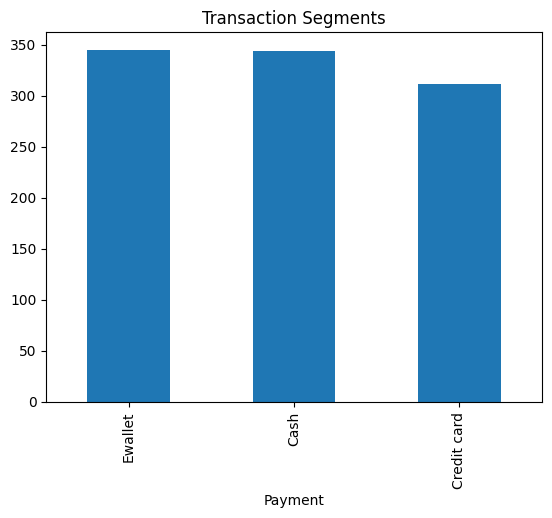

In [14]:
df['Payment'].value_counts().plot(kind='bar')

plt.title('Transaction Segments')

plt.show()

### Product revenue analysis

In [22]:
product_revenue = (
    df.groupby('Product line')['Total']
      .sum()
      .sort_values(ascending=False)
)
product_revenue


Product line
Food and beverages        56144.8440
Sports and travel         55122.8265
Electronic accessories    54337.5315
Fashion accessories       54305.8950
Home and lifestyle        53861.9130
Health and beauty         49193.7390
Name: Total, dtype: float64

### Revenue by each branch

In [25]:
branch_revenue = ( df.groupby('Branch')['Total'].sum())
branch_revenue

Branch
A    106200.3705
B    106197.6720
C    110568.7065
Name: Total, dtype: float64

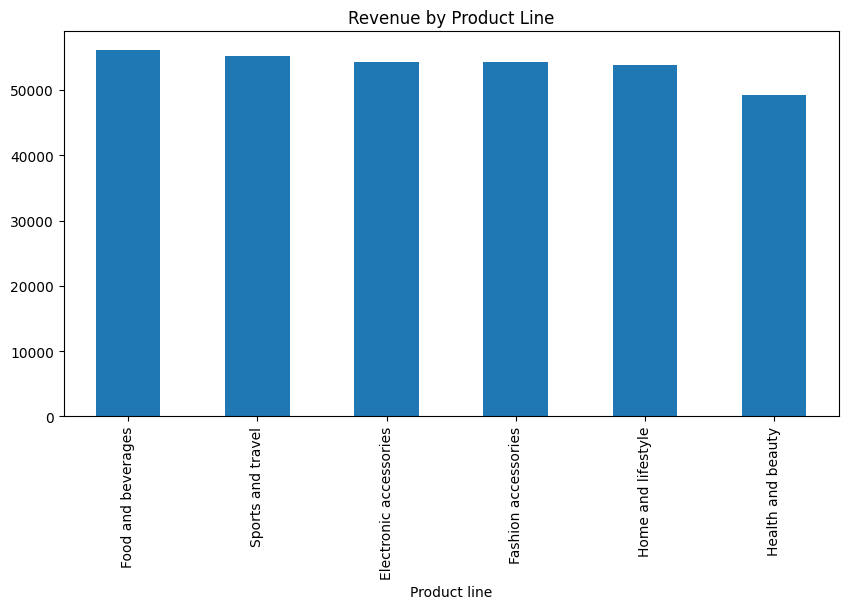

In [29]:
product_revenue.plot(
    kind='bar',
    figsize=(10,5),
    title = 'Revenue by Product Line'
)

plt.show()

### Pareto analysis

In [45]:
revenue = df.groupby('Product line')['Total'].sum().sort_values(ascending=False)

revenue_pct = revenue / revenue.sum() * 100

cumulative = np.cumsum(revenue_pct)

pareto_df = (pd.DataFrame({'REVENUE %':  revenue_pct , 'CUMULATIVE %' : cumulative }))

pareto_df

,REVENUE %,CUMULATIVE %
Product line,,
Food and beverages,17.384094,17.384094
Sports and travel,17.067648,34.451742
Electronic accessories,16.824497,51.276239
Fashion accessories,16.814702,68.090941
Home and lifestyle,16.677232,84.768172
Health and beauty,15.231828,100.000000


### Branch Performance

In [46]:
branch_analysis = (
    df.groupby('Branch')
      .agg(
          Revenue=('Total','sum'),
          Profit=('gross income','sum'),
          Avg_Rating=('Rating','mean'),
          Transactions=('Invoice ID','count')
      )
)

branch_analysis

,Revenue,Profit,Avg_Rating,Transactions
Branch,,,,
A,106200.3705,5057.1605,7.027059,340
B,106197.6720,5057.0320,6.818072,332
C,110568.7065,5265.1765,7.072866,328
